# Bank Customer Churn Prediction

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pickle

## 2. Load and Explore Data

We'll load the bank customer dataset and perform initial exploration.

In [ ]:
# Load data
bank_df = pd.read_csv("kaggle-data/train.csv", index_col="id", nrows=999)
print(f"Dataset shape: {bank_df.shape}")
bank_df.head()

Dataset shape: (999, 13)

First few rows:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [ ]:
# Dataset information
bank_df.info()
print(bank_df['Exited'].value_counts())
print(f"\nChurn Rate: {bank_df['Exited'].mean():.2%}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       999 non-null    int64  
 1   Surname          999 non-null    object 
 2   CreditScore      999 non-null    int64  
 3   Geography        999 non-null    object 
 4   Gender           999 non-null    object 
 5   Age              999 non-null    float64
 6   Tenure           999 non-null    int64  
 7   Balance          999 non-null    float64
 8   NumOfProducts    999 non-null    int64  
 9   HasCrCard        999 non-null    float64
 10  IsActiveMember   999 non-null    float64
 11  EstimatedSalary  999 non-null    float64
 12  Exited           999 non-null    int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 109.3+ KB
Target Variable Distribution (Exited):
Exited
0    796
1    203
Name: count, dtype: int64

Churn Rate: 20.32%


## 3. Data Cleaning and Preprocessing

Remove unnecessary columns and shuffle the data.

In [4]:
# Drop unnecessary columns
bank_df = bank_df.drop(['CustomerId', 'Surname'], axis=1)

# Shuffle the data
bank_df = bank_df.sample(frac=1, random_state=42)

print(f"After preprocessing: {bank_df.shape}")
print(f"Columns: {list(bank_df.columns)}")

After preprocessing: (999, 11)
Columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## 4. Split Data into Features and Target

- **Features (X)**: All columns except 'Exited'
- **Target (y)**: 'Exited' (1 = churned, 0 = stayed)

In [5]:
# Separate features and target
X = bank_df.drop(['Exited'], axis=1)
y = bank_df['Exited']

print(f"Features: {list(X.columns)}")
print(f"\nTarget distribution: {y.value_counts().to_dict()}")

Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Target distribution: {0: 796, 1: 203}


## 5. Train-Test Split

Split the data into:
- **70%** for training
- **30%** for testing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=125
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 699 samples
Testing set size: 300 samples


## 6. Identify Feature Types

We need to handle numerical and categorical features differently.

In [7]:
# Define categorical and numerical columns
cat_cols = ['Geography', 'Gender']
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

Categorical columns: ['Geography', 'Gender']
Numerical columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


## 7. Preprocess Numerical Features

**Steps:**
1. Impute missing values with **mean**
2. Scale features to **[0, 1]** range using MinMaxScaler

In [8]:
# Impute missing values with mean
imputer_num = SimpleImputer(strategy="mean")
X_train_num = imputer_num.fit_transform(X_train[num_cols])
X_test_num = imputer_num.transform(X_test[num_cols])
print("Imputed missing values (mean strategy)")

# Scale to [0, 1] range
scaler = MinMaxScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_test_num = scaler.transform(X_test_num)
print("Scaled features to [0, 1] range")
print(f"\nProcessed numerical features shape: {X_train_num.shape}")

Imputed missing values (mean strategy)
Scaled features to [0, 1] range

Processed numerical features shape: (699, 8)


## 8. Preprocess Categorical Features

**Steps:**
1. Impute missing values with **most frequent** value
2. Encode categories using **LabelEncoder**

In [9]:
# Impute missing values with most frequent
imputer_cat = SimpleImputer(strategy="most_frequent")
X_train_cat = imputer_cat.fit_transform(X_train[cat_cols])
X_test_cat = imputer_cat.transform(X_test[cat_cols])
print("Imputed missing values (most_frequent strategy)")

# Encode categorical variables
encoders = {}
X_train_cat_encoded = []
X_test_cat_encoded = []

for i, col in enumerate(cat_cols):
    le = LabelEncoder()
    X_train_cat_encoded.append(le.fit_transform(X_train_cat[:, i]))
    X_test_cat_encoded.append(le.transform(X_test_cat[:, i]))
    encoders[col] = le
    print(f"Encoded '{col}': {list(le.classes_)}")

X_train_cat_encoded = np.column_stack(X_train_cat_encoded)
X_test_cat_encoded = np.column_stack(X_test_cat_encoded)

print(f"\nProcessed categorical features shape: {X_train_cat_encoded.shape}")

Imputed missing values (most_frequent strategy)
Encoded 'Geography': ['France', 'Germany', 'Spain']
Encoded 'Gender': ['Female', 'Male']

Processed categorical features shape: (699, 2)


## 9. Combine All Features

Merge numerical and categorical features into a single feature matrix.

In [10]:
X_train_processed = np.hstack([X_train_num, X_train_cat_encoded])
X_test_processed = np.hstack([X_test_num, X_test_cat_encoded])

print(f"Combined features shape: {X_train_processed.shape}")
print(f" - {X_train_num.shape[1]} numerical features")
print(f" - {X_train_cat_encoded.shape[1]} categorical features")
print(f" - {X_train_processed.shape[1]} total features")

Combined features shape: (699, 10)
 - 8 numerical features
 - 2 categorical features
 - 10 total features


## 10. Train Random Forest Model

We use **Random Forest Classifier** with 75 trees.

In [11]:
model = RandomForestClassifier(
    n_estimators=75,
    max_depth=None,
    random_state=125
)
model.fit(X_train_processed, y_train)

RandomForestClassifier(n_estimators=75, random_state=125)

## 11. Model Evaluation

Evaluate the model using:
- **Accuracy**: Overall correctness
- **F1 Score**: Harmonic mean of precision and recall

In [12]:
predictions = model.predict(X_test_processed)
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average="macro")

print("MODEL PERFORMANCE")
print(f"Accuracy: {round(accuracy, 2) * 100}%")
print(f"F1 Score: {round(f1, 2)}")

MODEL PERFORMANCE
Accuracy: 86.0%
F1 Score: 0.73


## 12. Confusion Matrix

Visualize model performance with a confusion matrix.

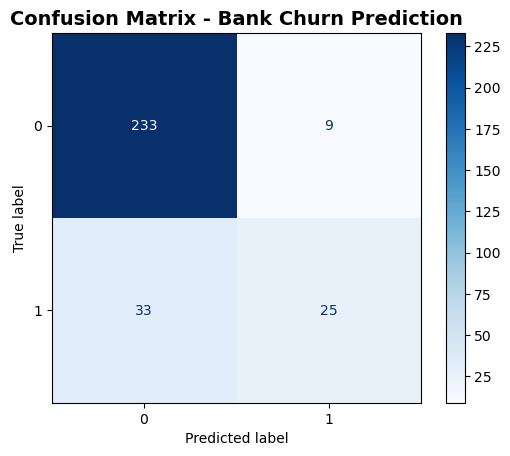

Confusion matrix saved as 'model_results.png'


In [13]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Bank Churn Prediction', fontsize=14, fontweight='bold')
plt.savefig("model_results.png", dpi=120, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'model_results.png'")

## 13. Feature Importance Analysis

Let's see which features are most important for predicting churn.

In [14]:
# Get feature importances
feature_importances = model.feature_importances_

# Create feature names (numerical + categorical)
all_feature_names = num_cols + cat_cols

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking:")
print(importance_df.to_string(index=False))

Feature Importance Ranking:
        Feature  Importance
            Age    0.274350
EstimatedSalary    0.150385
    CreditScore    0.131822
        Balance    0.118138
         Tenure    0.094621
  NumOfProducts    0.087851
         Gender    0.040044
      Geography    0.038749
 IsActiveMember    0.037980
      HasCrCard    0.026059


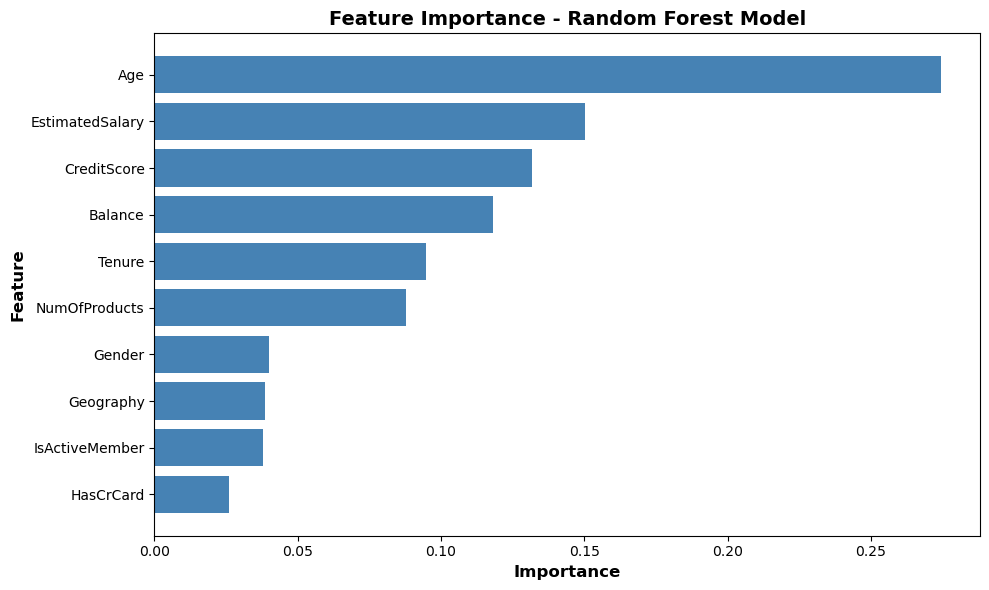


 Most important feature: Age


In [15]:
# Visualize feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Feature Importance - Random Forest Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n Most important feature: {importance_df.iloc[0]['Feature']}")

## 14. Save Metrics to File

In [16]:
# Write metrics to file
with open("metrics.txt", "w") as outfile:
    outfile.write(f"\nAccuracy = {round(accuracy, 2)}, F1 Score = {round(f1, 2)}\n\n")

print("Metrics saved to 'metrics.txt'")

# Display the content
with open("metrics.txt", "r") as infile:
    print("\nMetrics file content:")
    print(infile.read())

Metrics saved to 'metrics.txt'

Metrics file content:

Accuracy = 0.86, F1 Score = 0.73




## 15. Save Model and Preprocessing Objects

Save everything needed for making predictions on new data.

In [17]:
# Save model and preprocessing objects
model_artifacts = {
    'model': model,
    'imputer_num': imputer_num,
    'scaler': scaler,
    'imputer_cat': imputer_cat,
    'encoders': encoders,
    'num_cols': num_cols,
    'cat_cols': cat_cols
}

with open("bank_model.pkl", "wb") as f:
    pickle.dump(model_artifacts, f)

print("Model and preprocessing objects saved as 'bank_model.pkl'")
print("\nSaved artifacts include:")
for key in model_artifacts.keys():
    print(f"  - {key}")

Model and preprocessing objects saved as 'bank_model.pkl'

Saved artifacts include:
  - model
  - imputer_num
  - scaler
  - imputer_cat
  - encoders
  - num_cols
  - cat_cols


## 16. How to Use the Saved Model

Here's how to load and use the model for predictions on new data:

In [18]:
# Example: Load the model and make predictions
with open("bank_model.pkl", "rb") as f:
    loaded_artifacts = pickle.load(f)

## Summary

### What We Accomplished:

1. **Data Loading**: Loaded bank customer data (999 rows)
2. **Data Cleaning**: Removed unnecessary columns and shuffled data
3. **Train-Test Split**: 70% training, 30% testing
4. **Numerical Preprocessing**: Imputation (mean) + MinMax scaling
5. **Categorical Preprocessing**: Imputation (most frequent) + Label encoding
6. **Feature Combination**: Merged all features into single matrix
7. **Model Training**: Random Forest with 75 trees
8. **Evaluation**: Calculated accuracy and F1 score
9. **Visualization**: Created confusion matrix
10. **Feature Importance**: Identified most predictive features
11. **Persistence**: Saved model and preprocessing objects

### Key Outputs:
- `model_results.png` - Confusion matrix visualization
- `metrics.txt` - Performance metrics
- `bank_model.pkl` - Complete model package for deployment

### Next Steps:
- Experiment with different hyperparameters (n_estimators, max_depth)
- Try other algorithms (XGBoost, LightGBM)
- Perform cross-validation for more robust evaluation
- Deploy the model using the saved pickle file